# **Student Exam Score Predictor**

The objective is to develop a predictive model that estimates student performance based on multiple academic and personal factors such as previous scores, hours studied, attendance, motivation level, and access to resources. The goal is to identify the most influential features and build an interpretable, accurate model that generalizes well to unseen data, ultimately supporting better decision-making in educational planning and student support.

# **Importing Libraries**

In [88]:

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# **Loading Dataset**

In [89]:
df = pd.read_csv("student_dataset.csv")

In [90]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


**Hours_Studied**  
Number of hours a student studied (continuous numeric).

**Attendance**  
Percentage of classes attended (numeric, typically between 0–100).

**Parental_Involvement**  
Ordinal category: "Low", "Medium", "High". Reflects how engaged parents are in the student’s academics.

**Access_to_Resources**  
Ordinal category: "Low", "Medium", "High". Indicates the level of access to study materials, technology, or learning support.

**Extracurricular_Activities**  
Binary category: "Yes" or "No". Shows whether the student participates in extracurriculars.

**Sleep_Hours**  
Average hours of sleep per day (numeric).

**Previous_Scores**  
Past exam or test scores (numeric).

**Motivation_Level**  
Ordinal category: "Low", "Medium", "High". Represents the student’s self‑reported motivation.

**Internet_Access**  
Binary category: "Yes" or "No". Indicates whether the student has internet access at home.

**Tutoring_Sessions**  
Numeric count of tutoring sessions attended.

**Final_Exam_Score**  
Target variable (numeric). The student’s score in the final exam.

In [91]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


We can see there are no null values

In [92]:
df.shape

(6607, 11)

There are 6607 rows and 11 columns in entire dataset

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   object 
 3   Access_to_Resources         6607 non-null   object 
 4   Extracurricular_Activities  6607 non-null   object 
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   object 
 8   Internet_Access             6607 non-null   object 
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 567.9+ KB


In [94]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [95]:
numerical_features_list = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions", "Final_Exam_Score"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())

Parental_Involvement ['Low' 'Medium' 'High']
Access_to_Resources ['Low' 'High' 'Medium']
Extracurricular_Activities ['Yes' 'No']
Motivation_Level ['Medium' 'Low' 'High']
Internet_Access ['Yes' 'No']


In [96]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,20.472726,79.979068,7.185273,74.716059,1.488119,60.400333
std,5.988729,11.547717,1.290241,14.451962,1.216175,8.739400
min,1.100000,60.000000,4.000000,50.000000,0.000000,29.700000
25%,16.500000,70.000000,6.300000,62.100000,1.000000,54.300000
50%,20.500000,79.800000,7.200000,74.600000,1.000000,60.400000
75%,24.500000,90.200000,8.100000,87.400000,2.000000,66.600000
max,44.000000,100.000000,10.000000,100.000000,8.000000,95.200000


# **Univariate Analysis**

**Hours Studied**

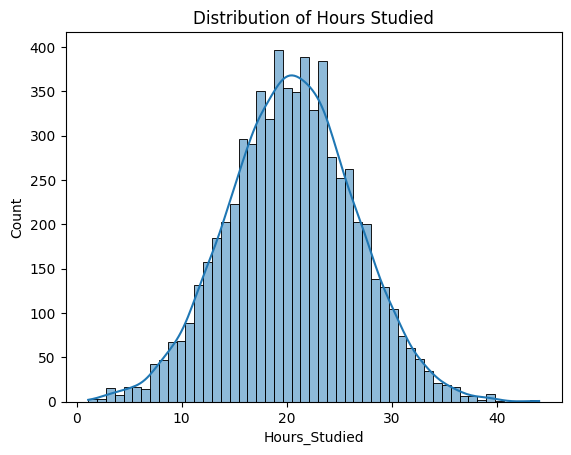

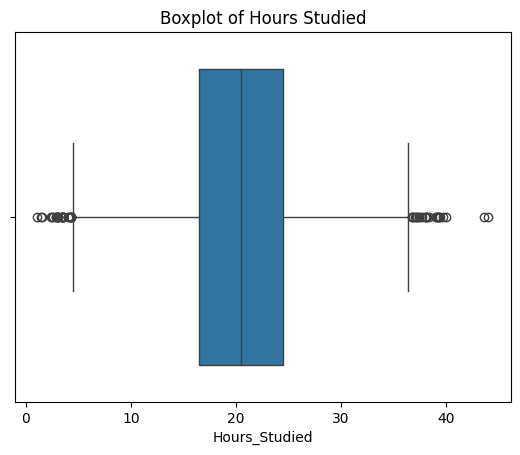

In [97]:
sns.histplot(df['Hours_Studied'], kde=True)
plt.title('Distribution of Hours Studied')
plt.show()

sns.boxplot(x=df['Hours_Studied'])
plt.title('Boxplot of Hours Studied')
plt.show()


The distribution is approximately normal (bell-shaped), centered around 20 hours.
Most students studied between 10 and 30 hours, showing that this is the typical range.
The smooth density curve confirms that the data is fairly symmetric, with no strong skew.

The median is around 20 hours, consistent with the histogram’s center.
The interquartile range (IQR) is roughly 15–25 hours, meaning half of the students fall within this range.
There are outliers, On the low end: students studying fewer than 5 hours. On the high end: students studying more than 35 hours.
These outliers suggest that while most students cluster around the average, a few study very little or extremely a lot.

**Attendance**

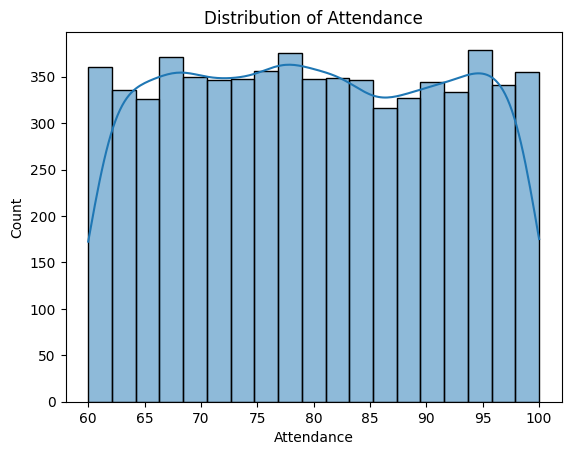

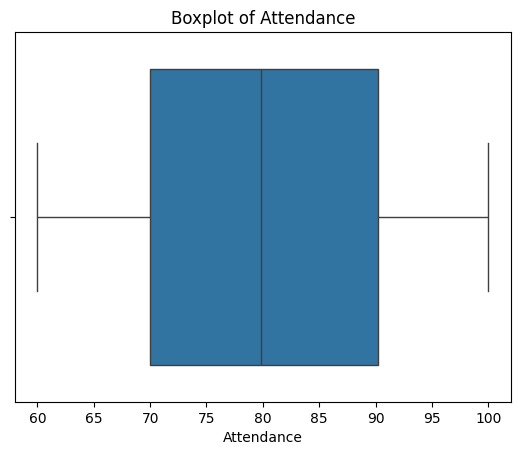

In [98]:
sns.histplot(df['Attendance'], kde=True)
plt.title('Distribution of Attendance')
plt.show()

sns.boxplot(x=df['Attendance'])
plt.title('Boxplot of Attendance')
plt.show()


This attendance plot shows a uniform spread from 60 to 100, meaning values are fairly evenly distributed. The median is around 80, with most students between 70 and 90, and whiskers stretching across the full range.

**Sleep Hours**

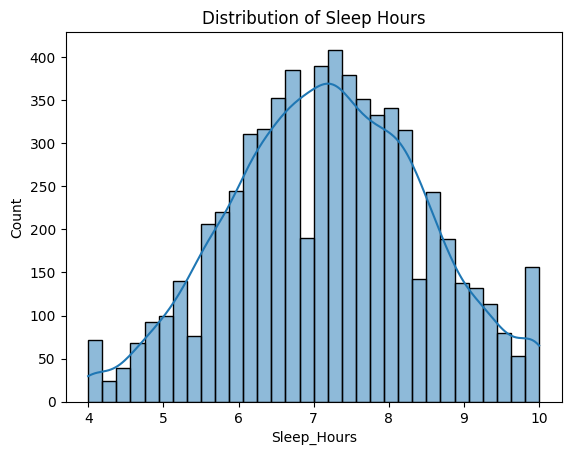

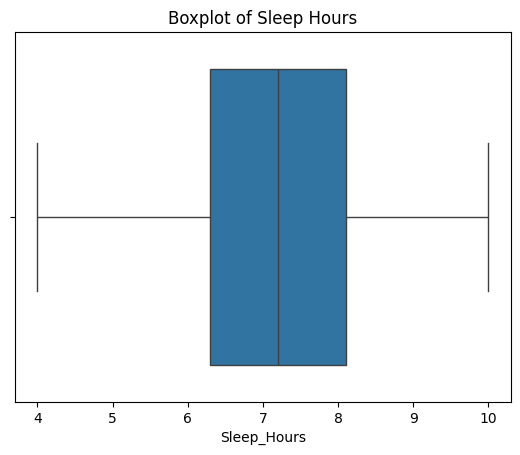

In [99]:
sns.histplot(df['Sleep_Hours'], kde=True)
plt.title('Distribution of Sleep Hours')
plt.show()

sns.boxplot(x=df['Sleep_Hours'])
plt.title('Boxplot of Sleep Hours')
plt.show()


This sleep data shows a normal distribution centered around 7 hours, with most people sleeping between 6 and 8 hours. The boxplot confirms the median at 7, whiskers stretching from about 4 to 10, and no extreme outliers.

**Previous Scores**

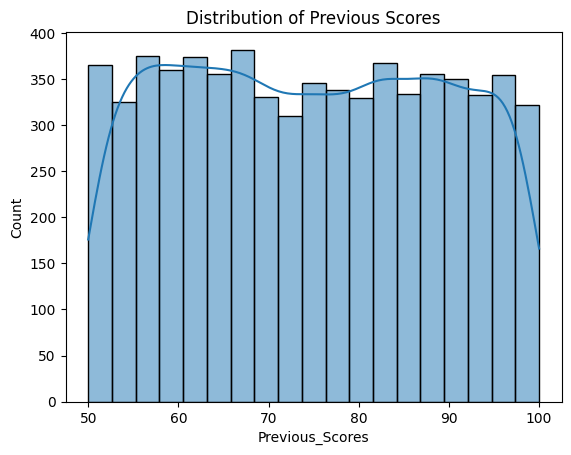

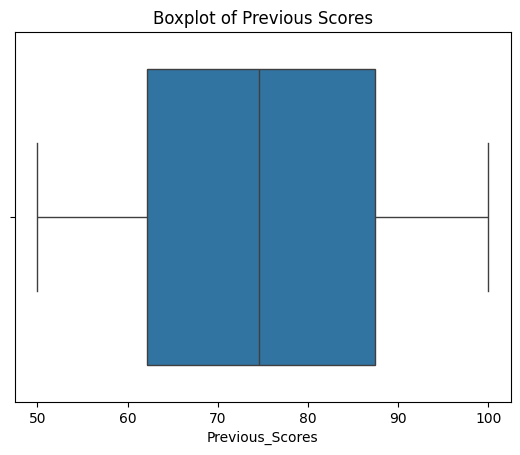

In [100]:
sns.histplot(df['Previous_Scores'], kde=True)
plt.title('Distribution of Previous Scores')
plt.show()

sns.boxplot(x=df['Previous_Scores'])
plt.title('Boxplot of Previous Scores')
plt.show()


This score data shows a uniform distribution from 50 to 100, meaning scores are spread fairly evenly across the range. The median is around 75, with most students between 60 and 90, and whiskers covering the full span from 50 to 100.

**Final Exam Score**

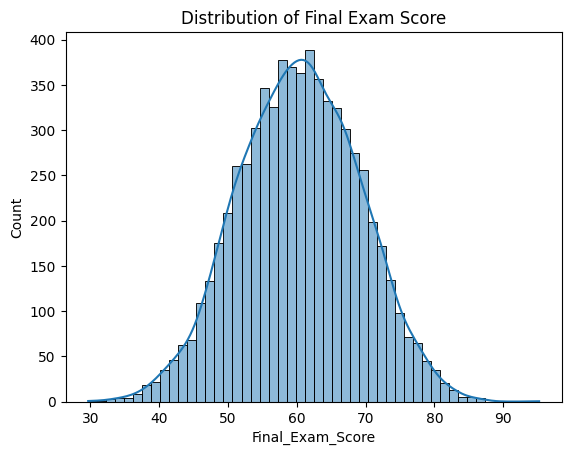

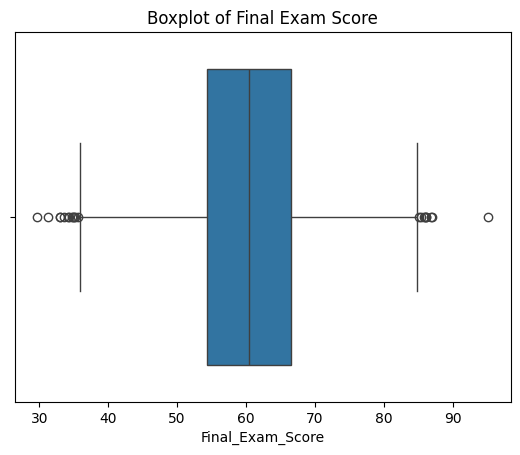

In [101]:
sns.histplot(df['Final_Exam_Score'], kde=True)
plt.title('Distribution of Final Exam Score')
plt.show()

sns.boxplot(x=df['Final_Exam_Score'])
plt.title('Boxplot of Final Exam Score')
plt.show()

Final exam scores are normally distributed around 60, with most students between 50–70 and a few outliers at both low and high ends.

**Parental Involvement**

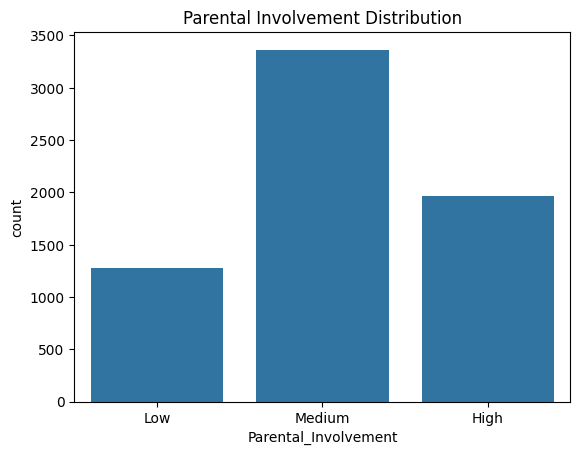

In [102]:
sns.countplot(x=df['Parental_Involvement'])
plt.title('Parental Involvement Distribution')
plt.show()

The chart shows that most students have medium parental involvement, followed by high, with low being the least common.

**Access to Resources**

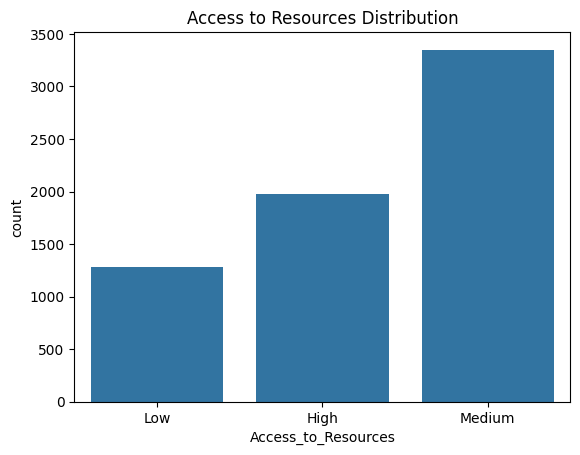

In [103]:
sns.countplot(x=df['Access_to_Resources'])
plt.title('Access to Resources Distribution')
plt.show()


The chart shows that most students fall into the medium category for access to resources, followed by high, with low being the least common.

**Extracurricular Activities**

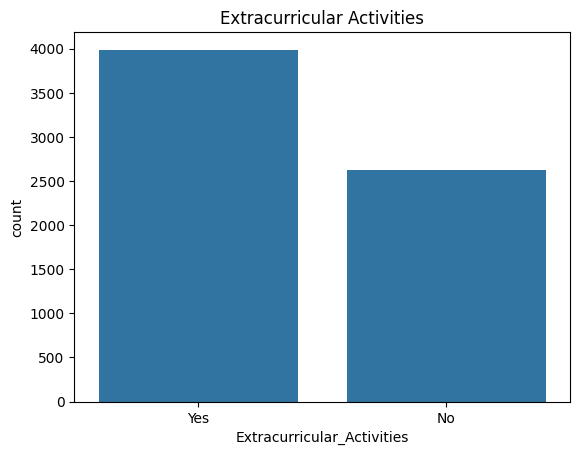

In [104]:
sns.countplot(x=df['Extracurricular_Activities'])
plt.title('Extracurricular Activities')
plt.show()

The chart shows that more students participate in extracurricular activities than those who don’t, with about 4000 saying “Yes” compared to around 2700 saying “No.”

**Motivation Level**

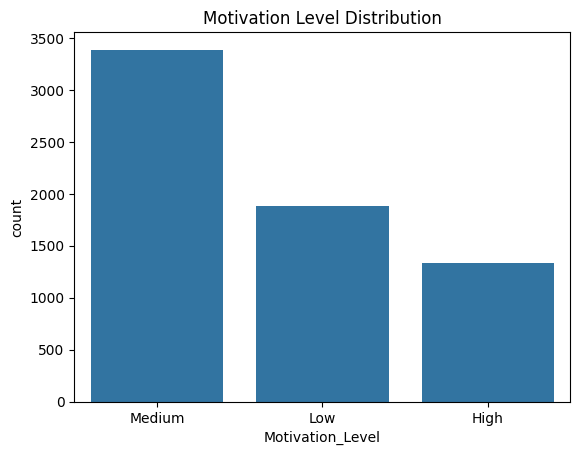

In [105]:
sns.countplot(x=df['Motivation_Level'])
plt.title('Motivation Level Distribution')
plt.show()

The chart shows that most students fall into the medium motivation level, followed by low, with high motivation being the least common.

**Internet Access**

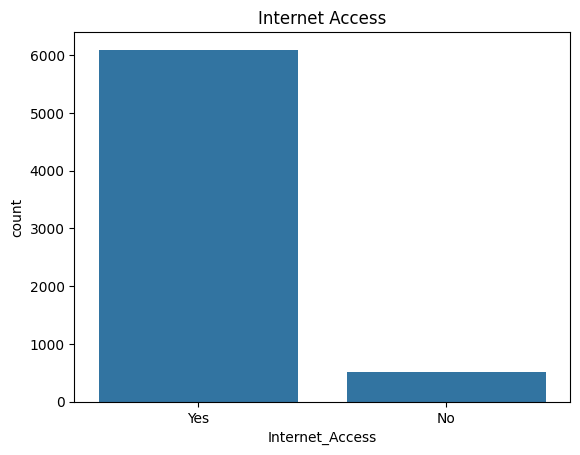

In [106]:
sns.countplot(x=df['Internet_Access'])
plt.title('Internet Access')
plt.show()

The chart shows that the vast majority of students have internet access (over 6000), while only a small group—around 500—do not.

**Tutoring Sessions**

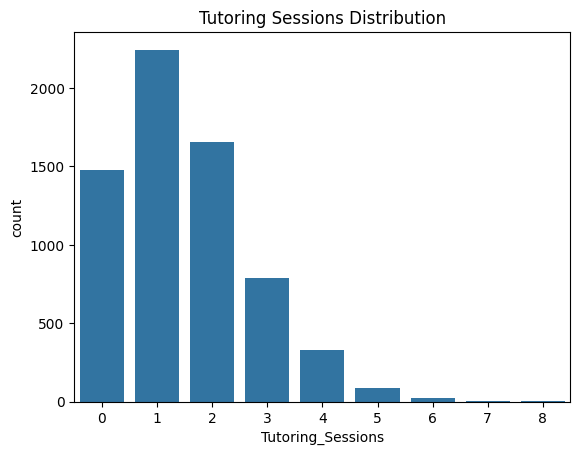

In [107]:
sns.countplot(x="Tutoring_Sessions", data=df)
plt.title("Tutoring Sessions Distribution")
plt.show()

The graph shows that most students attend very few tutoring sessions, with the highest frequency at just one session and steadily declining participation as the number of sessions increases.

# **Bivariate Analysis**

**Hours Studied v/s Final Exam Score**

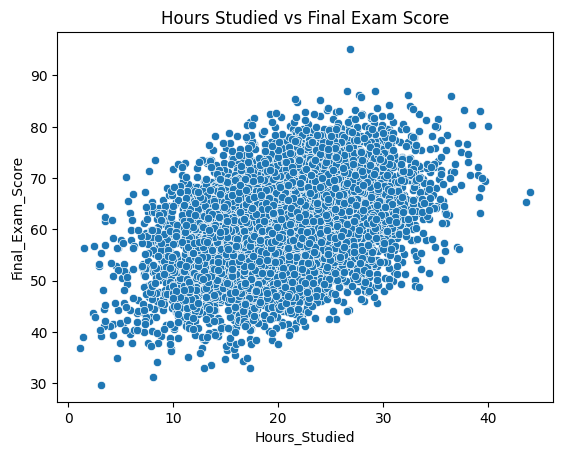

In [108]:
sns.scatterplot(
    x=df['Hours_Studied'],
    y=df['Final_Exam_Score']
)

plt.title('Hours Studied vs Final Exam Score')
plt.show()

This scatter plot shows a clear positive correlation: as hours studied increase, final exam scores also tend to rise, with most points clustering along an upward trend.

**Attendance v/s Final Exam Score**

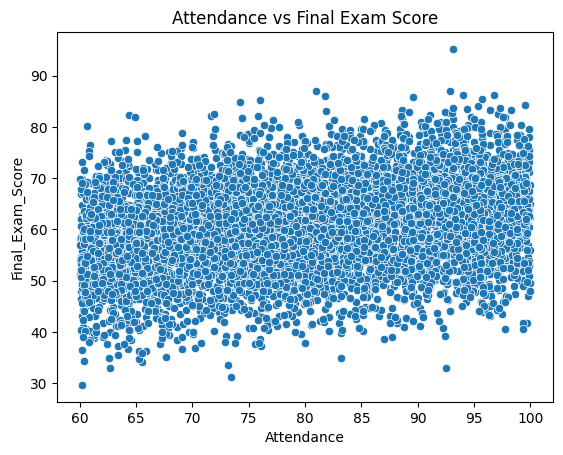

In [109]:
sns.scatterplot(
    x=df['Attendance'],
    y=df['Final_Exam_Score']
)

plt.title('Attendance vs Final Exam Score')
plt.show()

This scatter plot shows a positive relationship: higher attendance generally aligns with higher final exam scores, though the spread indicates that attendance alone doesn’t fully explain performance.

**Sleep Hours v/s Final Exam Score**

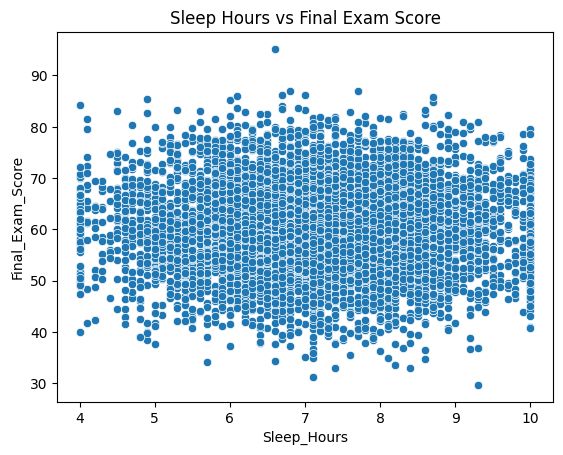

In [110]:
sns.scatterplot(
    x=df['Sleep_Hours'],
    y=df['Final_Exam_Score']
)

plt.title('Sleep Hours vs Final Exam Score')
plt.show()

This scatter plot shows no strong correlation: sleep hours range from 4–10, but exam scores vary widely across that range without a clear upward or downward trend.

**Previous Scores v/s Final Exam Score**

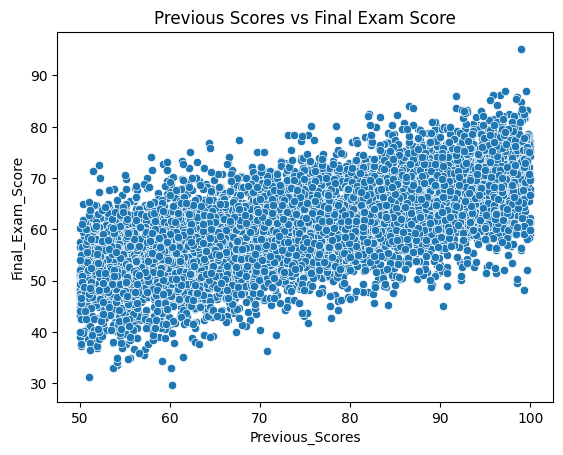

In [111]:
sns.scatterplot(
    x=df['Previous_Scores'],
    y=df['Final_Exam_Score']
)

plt.title('Previous Scores vs Final Exam Score')
plt.show()

This scatter plot shows a strong positive correlation: students with higher previous scores generally achieve higher final exam scores, with points clustering along an upward trend.

**Tutoring Sessions v/s Final Exam Score**

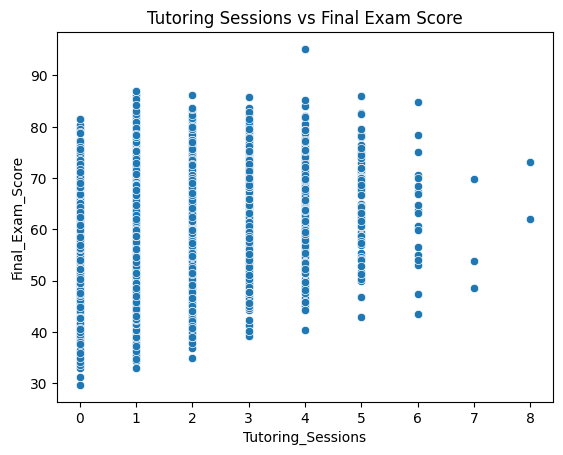

In [112]:
sns.scatterplot(
    x=df['Tutoring_Sessions'],
    y=df['Final_Exam_Score']
)

plt.title('Tutoring Sessions vs Final Exam Score')
plt.show()

This scatter plot shows a weak positive trend: students with more tutoring sessions sometimes achieve higher exam scores, but the relationship is not as clear or strong as with study hours or previous scores.

# **Multivariate Analysis**

**Hours Studied by Parental Involvement**

<Axes: xlabel='Hours_Studied', ylabel='Count'>

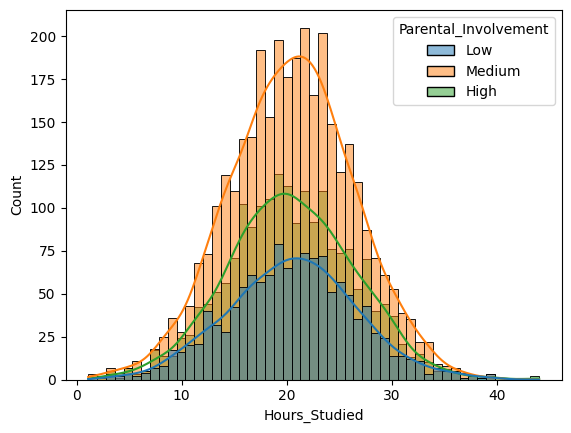

In [113]:
sns.histplot(data=df, x="Hours_Studied", hue="Parental_Involvement", kde=True)

Medium parental involvement corresponds to the highest concentration of study hours around 20, while low involvement shows fewer hours studied overall.

**Internet Access by Parental Involvement**

<Axes: xlabel='Internet_Access', ylabel='count'>

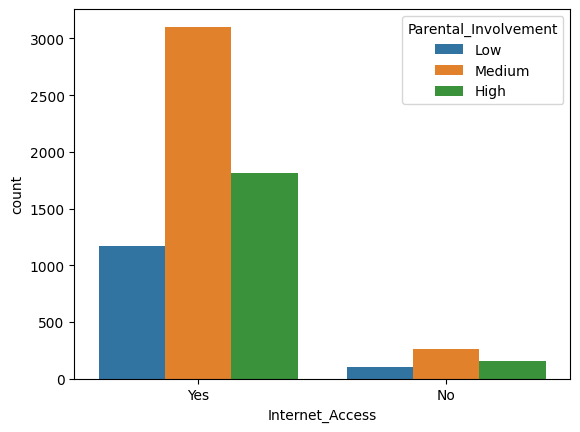

In [114]:
sns.countplot(data=df, x="Internet_Access", hue="Parental_Involvement")

This chart shows that most students with internet access fall into the medium parental involvement group, followed by high, and then low involvement — while those without internet access are very few across all categories.

**Tutoring Sessions v/s Parental Involvement**

<Axes: xlabel='Tutoring_Sessions', ylabel='count'>

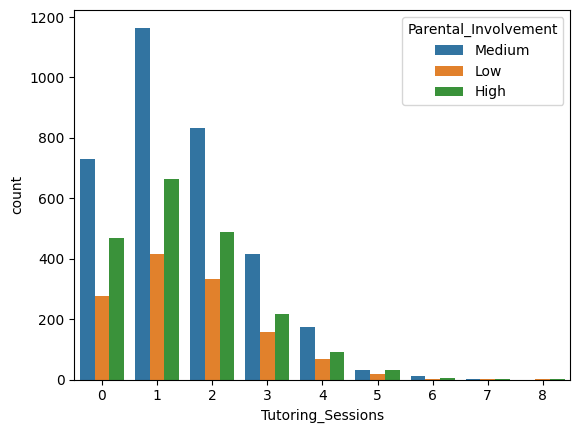

In [115]:
sns.countplot(data=df, x="Tutoring_Sessions", hue="Parental_Involvement")

This chart shows that students with medium parental involvement tend to have the highest counts for lower numbers of tutoring sessions, followed by those with high involvement, and then low involvement.

**Motivation Level by Parental Involvement**

<Axes: xlabel='Motivation_Level', ylabel='count'>

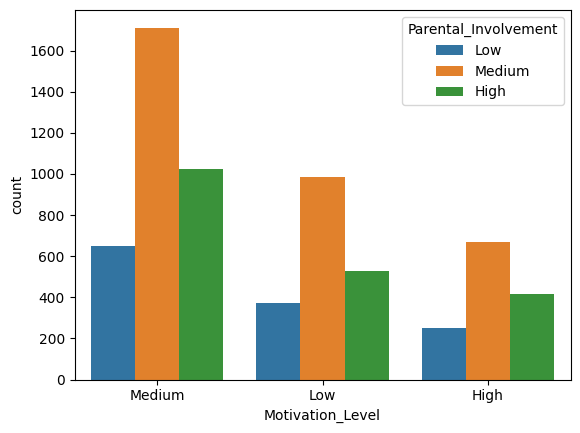

In [116]:
sns.countplot(data=df, x="Motivation_Level", hue="Parental_Involvement")

This grouped bar chart shows that medium parental involvement consistently corresponds to the highest counts across all motivation levels (low, medium, and high), followed by high involvement, with low involvement always being the least.

**Heatmap**

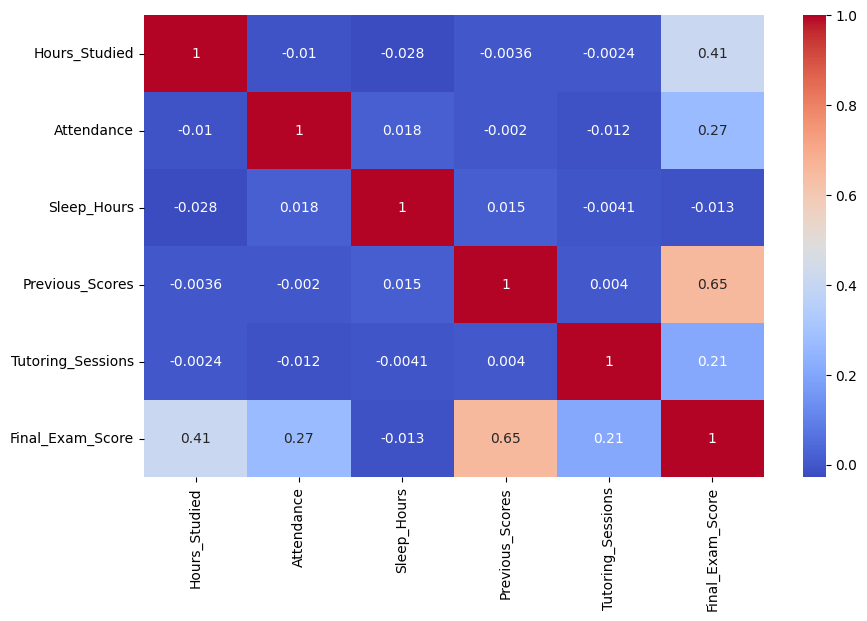

In [117]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

The correlation heatmap shows that Final Exam Score is most strongly linked to Previous Scores (0.65) and Hours Studied (0.41), followed by Attendance (0.27) and Tutoring Sessions (0.21), while Sleep Hours has almost no impact.

**Pairplot**

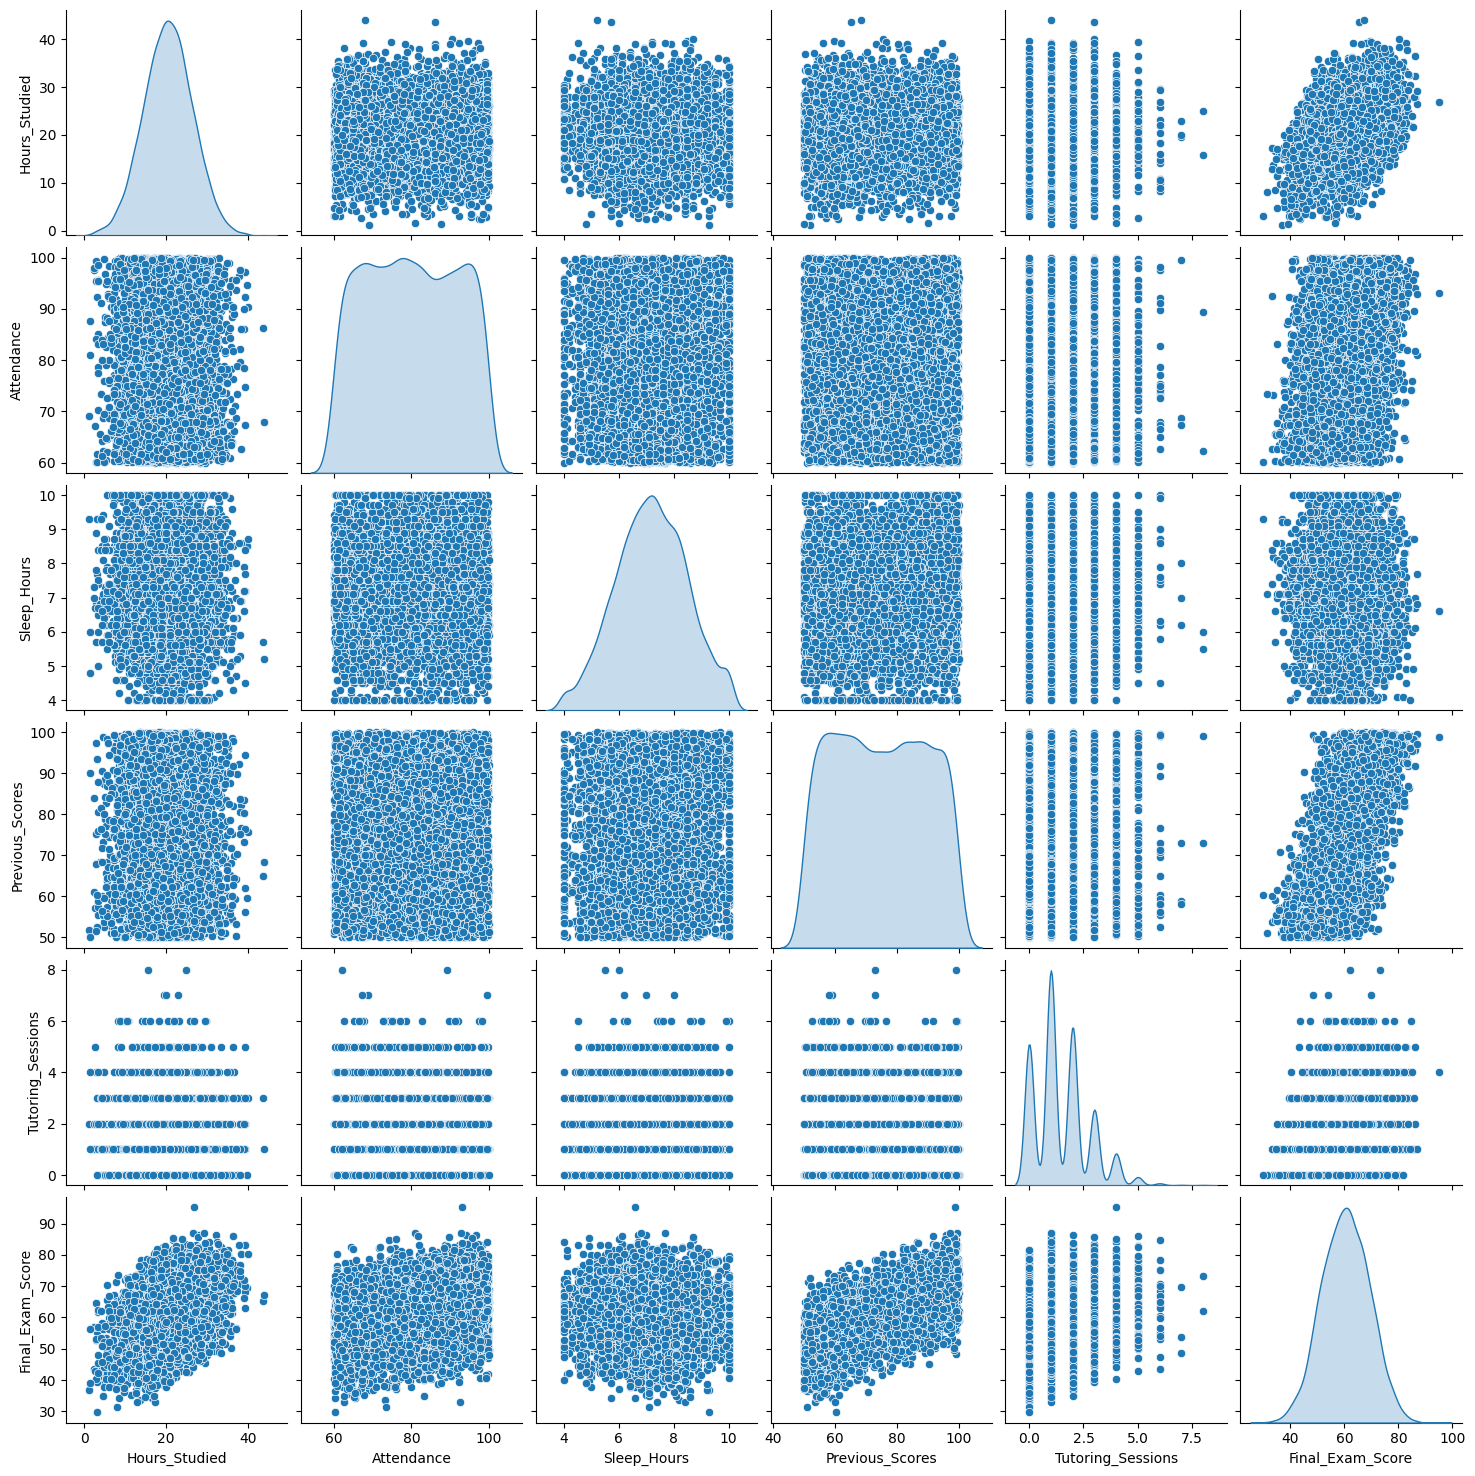

In [118]:
sns.pairplot(df,
             vars=["Hours_Studied", "Attendance", "Sleep_Hours",
                   "Previous_Scores", "Tutoring_Sessions", "Final_Exam_Score"],
             diag_kind="kde",
             hue=None)

plt.show()

# **Summary**

1.   Medium parental involvement, medium motivation, and medium access to resources dominate the dataset.
2.   Internet access is nearly universal.
3.   Extracurricular participation is common but not universal.
4.   Study hours and previous scores are the strongest predictors of final exam performance, while sleep has little impact.
5.   Parental involvement consistently influences patterns across motivation, tutoring, and internet access.



# **Data Preprocessing and Model Training**

**Encoding Binary Variables**

In [119]:
binary_cols = ["Extracurricular_Activities", "Internet_Access"]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})


In [120]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,1,7.4,50.3,Medium,1,1,54.3
1,19.7,63.6,Medium,High,1,6.7,83.1,Low,1,2,59.4
2,24.4,98.4,Medium,Medium,1,8.0,63.5,Medium,1,0,63.8
3,29.6,88.6,Medium,High,1,6.3,57.5,Medium,1,2,61.0
4,19.1,91.5,High,Medium,1,6.2,66.0,Medium,1,2,60.7


In [121]:
y = df["Final_Exam_Score"]
X = df.drop("Final_Exam_Score", axis=1)

ordinal_cols = ["Parental_Involvement", "Access_to_Resources", "Motivation_Level"]
numerical_cols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions"]


**Preprocessing with ColumnTransformer**

Applying scaling to numerical features and ordinal encoding to categorical features for a unified pipeline.

In [122]:
ordinal_transformer = OrdinalEncoder(categories=[["Low", "Medium", "High"],["Low", "Medium", "High"],["Low", "Medium", "High"]])

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("ord", ordinal_transformer, ordinal_cols)
    ],
    remainder="passthrough"
)


**Train Test Split**

we take 80% training set and 20% testing set

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Linear Regression**

In [124]:
from sklearn.linear_model import LinearRegression

lin_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lin))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lin))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))


Linear Regression R²: 0.7925164351386418
Linear Regression MAE: 3.22143866695286
Linear Regression RMSE: 4.014053281404044


**Decision Tree Regressor**

In [125]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(
        random_state=42,
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10
    ))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree R²:", r2_score(y_test, y_pred_tree))
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_tree))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))


Decision Tree R²: 0.6134665579284736
Decision Tree MAE: 4.3932797961108525
Decision Tree RMSE: 5.478792081083074


**SVM**

In [126]:
from sklearn.svm import SVR

svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", SVR(kernel="rbf"))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM R²:", r2_score(y_test, y_pred_svm))
print("SVM MAE:", mean_absolute_error(y_test, y_pred_svm))
print("SVM RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svm)))


SVM R²: 0.7709130026285694
SVM MAE: 3.3760855327695545
SVM RMSE: 4.217853607977128


**Random Forest**

In [127]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)
print("Random Forest R²:", r2_score(y_test, rf_model.predict(X_test)))



Random Forest R²: 0.7475183094908571


**Gradient Boost**

In [128]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])
gb_model.fit(X_train, y_train)
print("Gradient Boosting R²:", r2_score(y_test, gb_model.predict(X_test)))


Gradient Boosting R²: 0.7787678958327082


Printing all Results of R2 Score

In [129]:
results = {
    "Linear Regression": [r2_score(y_test, y_pred_lin)],
    "Decision Tree": [r2_score(y_test, y_pred_tree)],
    "SVM": [r2_score(y_test, y_pred_svm)],
    "Random Forest": [r2_score(y_test, rf_model.predict(X_test))],
    "Gradient Boosting": [r2_score(y_test, gb_model.predict(X_test))]
}

pd.DataFrame(results)


,Linear Regression,Decision Tree,SVM,Random Forest,Gradient Boosting
0,0.792516,0.613467,0.770913,0.747518,0.778768


**Applying K Folds Cross Validation**

In [130]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": lin_model,
    "Decision Tree": tree_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
    print(f"{name} CV Scores: {scores}")
    print(f"{name} Mean CV Score: {scores.mean()}")
    print("-"*40)


Linear Regression CV Scores: [0.79251644 0.78808191 0.78627923 0.81298251 0.79550896]
Linear Regression Mean CV Score: 0.7950738101396153
----------------------------------------
Decision Tree CV Scores: [0.61346656 0.60213916 0.60682151 0.62042996 0.62313112]
Decision Tree Mean CV Score: 0.6131976610962354
----------------------------------------
SVM CV Scores: [0.77091245 0.77204171 0.76448809 0.78655915 0.77211661]
SVM Mean CV Score: 0.7732236005415786
----------------------------------------
Random Forest CV Scores: [0.74744439 0.7507407  0.7492809  0.75998368 0.74751677]
Random Forest Mean CV Score: 0.7509932883067236
----------------------------------------
Gradient Boosting CV Scores: [0.7787679  0.77524804 0.77538505 0.79390576 0.78086635]
Gradient Boosting Mean CV Score: 0.7808346189700883
----------------------------------------


# **Hyper Parameter Tuning**

**Applying Grid search CV (Gradient Boost)**

In [131]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate": [0.05, 0.1, 0.2],
    "regressor__max_depth": [3, 5, 7]
}

grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_gb = grid_search.best_estimator_
y_pred = best_gb.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Test R²: 0.7792041141146656
Best Parameters: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}
Best CV Score: 0.7804074175356637


**Applying Grid Search CV (Ridge Regression)**

In [132]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

param_grid_ridge = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(
    ridge_model,
    param_grid_ridge,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search_ridge.fit(X_train, y_train)
best_ridge = grid_search_ridge.best_estimator_
y_pred = best_ridge.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))

print("Best Parameters (Ridge):", grid_search_ridge.best_params_)
print("Best CV Score (Ridge):", grid_search_ridge.best_score_)


Test R²: 0.7924975763129177
Best Parameters (Ridge): {'regressor__alpha': 10}
Best CV Score (Ridge): 0.7957498899484536


**Applying Grid Search CV (Lasso Regression)**

In [133]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(max_iter=10000))
])

param_grid_lasso = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid_search_lasso = GridSearchCV(
    lasso_model,
    param_grid_lasso,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search_lasso.fit(X_train, y_train)
best_lasso = grid_search_lasso.best_estimator_
y_pred = best_lasso.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("Best Parameters (Lasso):", grid_search_lasso.best_params_)
print("Best CV Score (Lasso):", grid_search_lasso.best_score_)


Test R²: 0.7924547557783487
Best Parameters (Lasso): {'regressor__alpha': 0.01}
Best CV Score (Lasso): 0.7958055785705247


**Applying Grid Search CV (SVM)**

In [134]:
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SVR())
])

param_grid = {
    "regressor__kernel": ["linear", "rbf"],
    "regressor__C": [0.1, 1, 10],
    "regressor__gamma": ["scale", "auto"]
}

grid = GridSearchCV(svm_model, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test R²:", r2_score(y_test, grid.predict(X_test)))

Best Params: {'regressor__C': 0.1, 'regressor__gamma': 'scale', 'regressor__kernel': 'linear'}
Best CV Score: 0.7954931747804395
Test R²: 0.7921813526717201


**Applying Grid Search CV (Adaboost)**

In [135]:
from sklearn.ensemble import AdaBoostRegressor
ada_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", AdaBoostRegressor(random_state=42))
])

param_grid = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__learning_rate": [0.01, 0.1, 1]
}

grid = GridSearchCV(ada_model, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test R²:", r2_score(y_test, grid.predict(X_test)))

Best Params: {'regressor__learning_rate': 1, 'regressor__n_estimators': 200}
Best CV Score: 0.7425674324404582
Test R²: 0.7374385137556213


**Summary:**

1.   Your dataset is highly linear — Linear Regression, Ridge, Lasso, and linear SVM all cluster around ~0.795 CV score.
2.   Regularization (Ridge/Lasso) doesn’t improve much, but helps prevent overfitting.
3.   SVM (linear kernel) performs almost identically to Ridge/Lasso, confirming linear separability.
4.   Gradient Boosting and AdaBoost lag behind, meaning complex nonlinear ensembles don’t add much value here.
5.   Decision Tree is unstable and clearly not suitable.

Linear Regression Mean CV Score: 0.7950738101396153
Linear Regression R²: 0.7925164351386417

Test R²: 0.7924975763129178
Best Parameters (Ridge): {'regressor__alpha': 10}
Best CV Score (Ridge): 0.7957498899484537

Test R²: 0.7924547557783487
Best Parameters (Lasso): {'regressor__alpha': 0.01}
Best CV Score (Lasso): 0.7958055785705247

We choose **Lasso Regression** as the optimal model. It delivers the same strong accuracy as Ridge and Linear Regression, while also performing **feature selection** through **L1 regularization** — making the model *simpler, more interpretable, and robust against overfitting*.

# **Selected Model: Lasso Regression**

# **Final Model Implementation and Evaluation**

**loading dataset**

In [136]:
df = pd.read_csv("student_dataset.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


In [137]:
y = df["Final_Exam_Score"]
X = df.drop("Final_Exam_Score", axis=1)
ordinal_cols = ["Parental_Involvement", "Access_to_Resources", "Motivation_Level"]
numerical_cols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions"]


**train test split**

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [139]:
X_train.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions
5810,27.1,78.7,Medium,High,Yes,7.9,67.6,Medium,Yes,1
1268,16.1,85.7,High,Medium,No,7.7,79.4,Low,Yes,3
414,22.5,87.5,Medium,High,Yes,8.1,71.0,Medium,Yes,1
4745,18.8,99.8,Medium,Low,No,7.3,67.5,Medium,Yes,1
654,35.9,78.2,Medium,Low,No,8.1,54.3,Medium,Yes,1


In [140]:
continuous_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions']
ordinal_features    = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level']
binary_features     = ['Extracurricular_Activities', 'Internet_Access']

**Preprocessing using Column Transformer**

In [141]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('ord', OrdinalEncoder(categories=[["Low","Medium","High"],
                                           ["Low","Medium","High"],
                                           ["Low","Medium","High"]]), ordinal_features),
        ('bin', OrdinalEncoder(categories=[["No","Yes"],["No","Yes"]]), binary_features)
    ]
)

**Creating Pipeline**

with alpha = 0.01

In [142]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.01, max_iter=10000))
])

**Model Training**

In [143]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# **Performance Evaluation**

In [144]:
print("Test R²:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train R²:", r2_score(y_train, pipeline.predict(X_train)))

Test R²: 0.7924547557783487
Test MAE: 3.2210121834797443
Test RMSE: 4.014649872853159
Train R²: 0.7971550086200788


**Residual Plot**

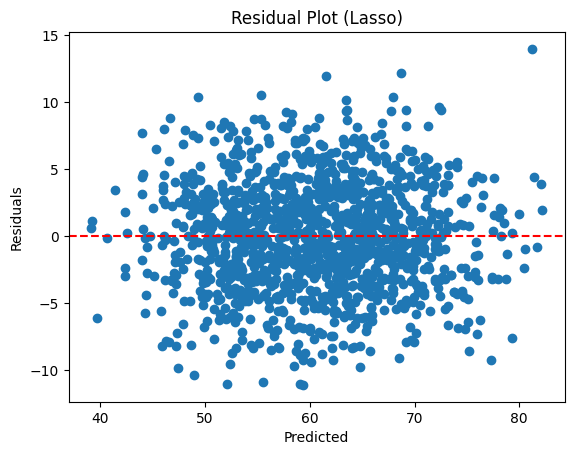

In [145]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (Lasso)")
plt.show()


Residuals are randomly scattered around zero, indicating no clear bias and a good model fit

**Train vs Test Predictions**

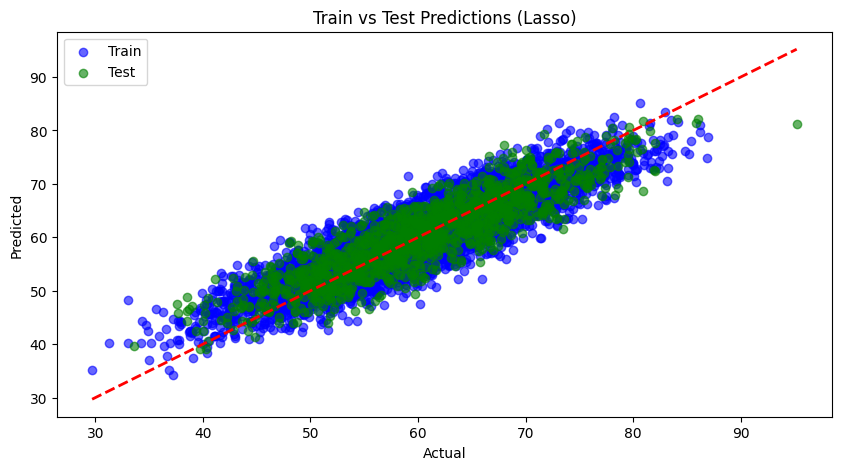

In [146]:
import matplotlib.pyplot as plt
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

plt.figure(figsize=(10,5))
plt.scatter(y_train, y_train_pred, color="blue", alpha=0.6, label="Train")
plt.scatter(y_test, y_test_pred, color="green", alpha=0.6, label="Test")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Train vs Test Predictions (Lasso)")
plt.legend()
plt.show()


Predicted values closely align with actual outcomes for both train and test sets, confirming strong model accuracy and generalization.

**Feature Importance**

Previous Scores, Hours Studied, and Motivation Level are the strongest positive predictors, while Parental Involvement is shrunk to zero, highlighting Lasso’s feature selection ability.

In [147]:
coeffs = pipeline.named_steps["regressor"].coef_
features = numerical_cols + ordinal_cols + binary_cols
coef_df = pd.DataFrame({"Feature": features, "Coefficient": coeffs})
print(coef_df.sort_values(by="Coefficient", ascending=False))

                      Feature  Coefficient
3             Previous_Scores     5.709725
0               Hours_Studied     3.560421
7            Motivation_Level     2.977955
1                  Attendance     2.416371
6         Access_to_Resources     1.969915
4           Tutoring_Sessions     1.780659
8  Extracurricular_Activities     0.123387
9             Internet_Access     0.100502
5        Parental_Involvement     0.000000
2                 Sleep_Hours    -0.066301


We fit the full dataset at the very end to retrain the chosen model on all available data, ensuring it learns from maximum information before deployment.

In [148]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Hours_Studied',
                                                   'Attendance', 'Sleep_Hours',
                                                   'Previous_Scores',
                                                   'Tutoring_Sessions']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['Parental_Involvement',
                                                   'Access_to_Resources',
                                                   'Motivation_Level']),
                                                 ('bin',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes']]),
                                                  ['Extracurricular_Activities',
                                                   'Internet_Access'])])),
                ('regressor', Lasso(alpha=0.01, max_iter=10000))])

# **Model Serialization with Pickle**

In [149]:
import joblib
joblib.dump(pipeline, "exam_score_predictor.pkl")

['exam_score_predictor.pkl']

# **Model Loading and Prediction**

In [150]:
loaded_model = joblib.load("exam_score_predictor.pkl")

In [151]:
user_input = {
    "Hours_Studied": [13.4],
    "Attendance": [75.5],
    "Parental_Involvement": ["Medium"],
    "Motivation_Level": ["Medium"],
    "Access_to_Resources": ["Medium"],
    "Sleep_Hours": [7.3],
    "Previous_Scores": [54.5],
    "Internet_Access": ["Yes"],
    "Tutoring_Sessions": [4],
    "Extracurricular_Activities": ["Yes"]
}

user_df = pd.DataFrame(user_input)
user_pred = loaded_model.predict(user_df)
print("Predicted exam score:", user_pred[0])


Predicted exam score: 51.071985068448974


Predicted: 51.072,
Actual: 47.5

# **Conclusion**

The dataset proved to be highly **linear**, with Linear Regression, Ridge, Lasso, and linear SVM all achieving strong and consistent performance around an R² of ~0.79. Among these, **Lasso Regression** was selected as the optimal model since it not only matched the best accuracy but also provided feature selection, simplifying the model and improving interpretability. Residual and prediction plots confirmed **good generalization with no major bias**, and the final pipeline was retrained on the full dataset and serialized for deployment. Overall, the modeling process demonstrates that a regularized linear approach is both accurate and practical for this problem.